In [1]:
%load_ext autoreload
%autoreload 2
    
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(0)

n = 200
theta = np.linspace(0, 2*np.pi, n, endpoint=False)

r = 1.0
X_clean = np.vstack([
    r * np.cos(theta),
    r * np.sin(theta)
]).T

# Add geometric noise
X = X_clean + 0.05 * np.random.randn(n, 2)

# True tangent velocity
V_true = np.vstack([
    -np.sin(theta),
    np.cos(theta)
]).T

# Add velocity noise
V = V_true + 0.6 * np.random.randn(n, 2)

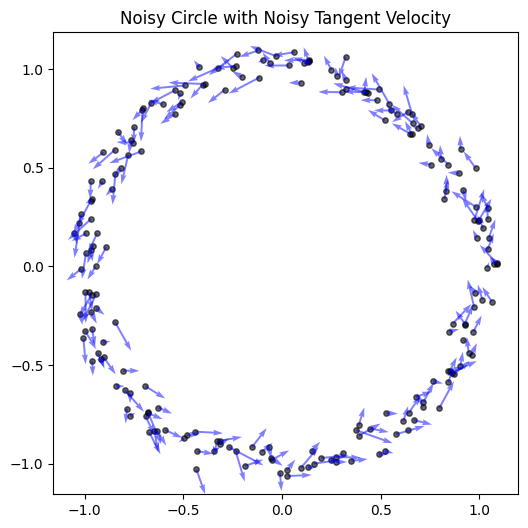

In [2]:
plt.figure(figsize=(6,6))

plt.scatter(X[:,0], X[:,1], s=15, color='black', alpha=0.6)

plt.quiver(
    X[:,0], X[:,1],
    V[:,0], V[:,1],
    color='blue',
    alpha=0.5,
    scale=30
)

plt.title("Noisy Circle with Noisy Tangent Velocity")
plt.axis('equal')
plt.show()

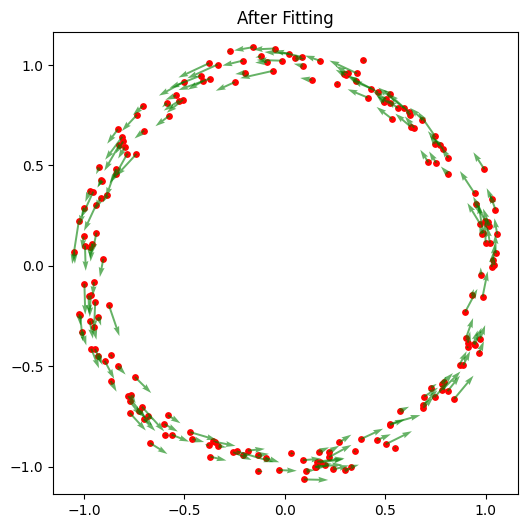

In [3]:
from manfit_velocity import VelocityManifoldFitter

# run solver
solver = VelocityManifoldFitter(
    Y=X,
    W=V,
    k=15,
    d=1,
    alpha=0.9,
    T=15,
    h=1.0,
    theta=0.8,
    use_abs_cos=True,
    recompute_neighbors=False
)

X_fit = solver.fit()


# ---- plot ----
plt.figure(figsize=(6,6))

plt.scatter(X_fit[:,0], X_fit[:,1], s=15, color='red')

plt.quiver(
    X_fit[:,0], X_fit[:,1],
    solver.v[:,0], solver.v[:,1],
    color='green',
    alpha=0.6,
    scale=30
)

plt.title("After Fitting")
plt.axis('equal')
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


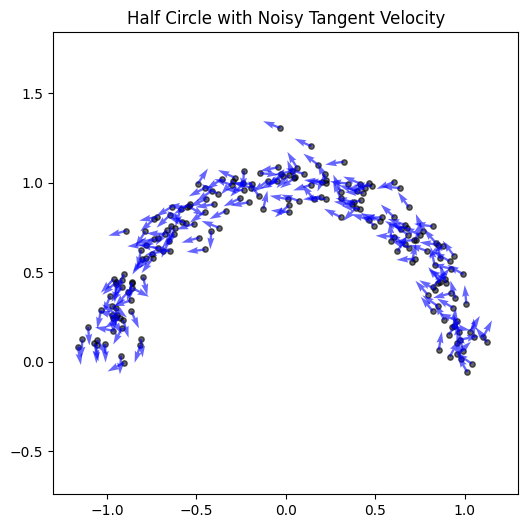

In [12]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

# ----------------------------
# 1. Half circle geometry
# ----------------------------
n = 200
theta = np.linspace(0, np.pi, n)   # <-- half circle

r = 1.0
X_clean = np.vstack([
    r * np.cos(theta),
    r * np.sin(theta)
]).T

# ----------------------------
# 2. Add geometric noise
# ----------------------------
X = X_clean + 0.08 * np.random.randn(n, 2)

# ----------------------------
# 3. True tangent velocity
# ----------------------------
V_true = np.vstack([
    -np.sin(theta),
    np.cos(theta)
]).T

# normalize (optional but cleaner visually)
V_true = V_true / (np.linalg.norm(V_true, axis=1, keepdims=True) + 1e-8)

# ----------------------------
# 4. Add velocity noise
# ----------------------------
V = V_true + 0.6 * np.random.randn(n, 2)

# normalize again so arrows don't go crazy
V = V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-8)

# ----------------------------
# 5. Plot
# ----------------------------
plt.figure(figsize=(6,6))

# points
plt.scatter(X[:,0], X[:,1], s=15, color='black', alpha=0.6)

# velocity field
plt.quiver(
    X[:,0], X[:,1],
    V[:,0], V[:,1],
    color='blue',
    alpha=0.6,
    scale=25,
    width=0.005
)

plt.title("Half Circle with Noisy Tangent Velocity")
plt.axis('equal')
plt.xlim(-1.3, 1.3)
plt.ylim(-0.2, 1.3)
plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


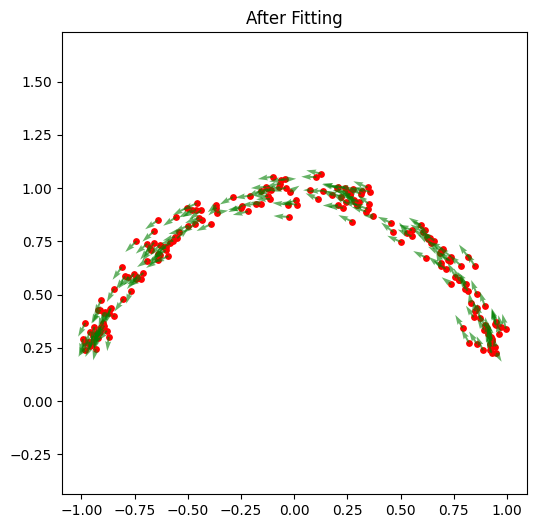

In [18]:
%load_ext autoreload
%autoreload 2

from manfit_velocity import VelocityManifoldFitter

# run solver
solver = VelocityManifoldFitter(
    Y=X,
    W=V,
    k=30,
    d=1,
    alpha=0.1,
    T=15,
    h=1.0,
    theta=0.8,
    use_abs_cos=True,
    recompute_neighbors=False
)

X_fit = solver.fit(mode="unweighted")


# ---- plot ----
plt.figure(figsize=(6,6))

plt.scatter(X_fit[:,0], X_fit[:,1], s=15, color='red')

plt.quiver(
    X_fit[:,0], X_fit[:,1],
    solver.v[:,0], solver.v[:,1],
    color='green',
    alpha=0.6,
    scale=30
)

plt.title("After Fitting")
plt.axis('equal')
plt.show()








solver = VelocityManifoldFitter(
    Y=X,
    W=V,
    k=30,
    d=1,
    alpha=0.1,
    T=15,
    h=1.0,
    theta=0.8,
    use_abs_cos=True,
    recompute_neighbors=False
)

X_fit = solver.fit(mode="weighted")


# # ---- plot ----
# plt.figure(figsize=(6,6))

# plt.scatter(X_fit[:,0], X_fit[:,1], s=15, color='red')

# plt.quiver(
#     X_fit[:,0], X_fit[:,1],
#     solver.v[:,0], solver.v[:,1],
#     color='green',
#     alpha=0.6,
#     scale=30
# )

# plt.title("After Fitting")
# plt.axis('equal')
# plt.show()

In [8]:
import time
import numpy as np

def generate_data(n):
    theta = np.linspace(0, 2*np.pi, n, endpoint=False)

    r = 1.0
    X_clean = np.vstack([
        r * np.cos(theta),
        r * np.sin(theta)
    ]).T

    X = X_clean + 0.05 * np.random.randn(n, 2)

    V_true = np.vstack([
        -np.sin(theta),
        np.cos(theta)
    ]).T

    V = V_true + 0.6 * np.random.randn(n, 2)

    return X, V


def run_scaling_test(sizes):
    results = []

    for n in sizes:
        print(f"\n=== n = {n} ===")
        try:
            X, V = generate_data(n)

            solver = VelocityManifoldFitter(
                Y=X,
                W=V,
                k=15,
                d=1,
                alpha=0.5,
                T=10,  # reduce for large n
                h=1.0,
                theta=0.8,
                use_abs_cos=True,
                recompute_neighbors=False,
                candidate_mult=3
            )

            start = time.time()
            solver.fit()
            elapsed = time.time() - start

            print(f"Time: {elapsed:.2f} sec")
            results.append((n, elapsed))

        except Exception as e:
            print(f"Failed at n={n}: {e}")
            results.append((n, None))

    return results


sizes = [100, 1000, 10000, 100000]
results = run_scaling_test(sizes)

print("\nResults:")
for n, t in results:
    print(f"{n:>7} : {t}")


=== n = 100 ===
Time: 0.05 sec

=== n = 1000 ===
Time: 0.21 sec

=== n = 10000 ===
Time: 2.07 sec

=== n = 100000 ===
Time: 21.92 sec

Results:
    100 : 0.04924416542053223
   1000 : 0.2080080509185791
  10000 : 2.072082757949829
 100000 : 21.916640281677246


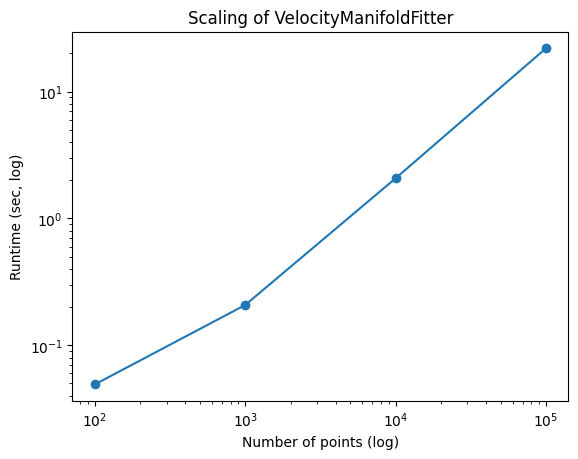

In [9]:
import matplotlib.pyplot as plt

valid = [(n, t) for n, t in results if t is not None]
ns, ts = zip(*valid)

plt.figure()
plt.plot(ns, ts, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Number of points (log)")
plt.ylabel("Runtime (sec, log)")
plt.title("Scaling of VelocityManifoldFitter")
plt.show()